# Event Cluster Summary - Single-cluster analysis

Analysis of event summaries from NEXT-100, focusing on single-cluster events.
Study of energy reconstruction, scatter hit contribution, and peak fitting.

**Date**: 25/08/05 CERN

## Purpose
- Filter events to those with exactly 1 cluster (single track)
- Apply Kr energy correction and study energy distributions
- Select double-escape (DE) events (1600-1750 keV)
- Analyze scatter hit fractions and their effect on energy resolution
- Fit calibration peaks at 511, 583, 727, 1592, 2615 keV

## Data
- Run 15607, CSV event summaries from Sophronia processing
- Kr correction maps from `/data/NEXT100/data/krmaps/`

**Note**: Development notebook with exploratory code. Functions later consolidated into `hefunc.py`.

In [9]:
%matplotlib inline
%reload_ext autoreload
%autoreload 2

In [10]:
import re
import glob
import sys
from os import listdir
from collections import namedtuple


In [11]:
import numpy             as np
import pandas            as pd
import tables            as tb
from   scipy             import stats
from   scipy             import optimize

import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import axes3d

plt.rcParams['image.cmap'] = 'rainbow'

In [12]:
pypaths = ('/Users/hernando/work/investigacion/NEXT/software/nextana',
           '/Users/hernando/work/investigacion/NEXT/software/hipy', 
           '/Users/hernando/work/investigacion/NEXT/software/IC')
for ipypath in pypaths:
       sys.path.insert(0,ipypath)

In [13]:
import hipy.utils        as ut
import hipy.histos       as histos
import hipy.pltext       as pltext
import hipy.profile      as prof

import nana.he100.hefunc as he100

from invisible_cities.io.dst_io import load_dst, load_dsts
pltext.style()

In [18]:
run_number = 15607
path_data = f"/Users/hernando/work/investigacion/NEXT/data/NEXT100/data/{run_number}/datini/"

filenames = listdir(path_data)
filenames.sort()
filenames = [file for file in filenames if file.find('.csv') > 0]
print('number of files :', len(filenames))
print('fist files: ', filenames[0], ', ', filenames[-1])


number of files : 7
fist files:  15607_ldc1_proc.csv ,  15607_ldc7_proc.csv


In [19]:
dsts = [pd.read_csv(path_data + ifile) for ifile in filenames]
dsts = pd.concat(dsts, ignore_index = True)


In [22]:
dsts[dsts.event == 932]

,Unnamed: 0,event,Z_min,Z_max,cluster,Ec_sum,X_mean,X_min,X_max,Y_mean,Y_min,Y_max
4,4,932,724.007375,737.951125,-1,4.969801,-27.553714,-435.975,443.375,23.391297,-433.275,446.075
5,5,932,737.951125,840.946625,-1,15535.298507,-27.553714,-435.975,443.375,23.391297,-433.275,446.075
6,6,932,737.951125,840.946625,0,296680.307974,-128.093302,-235.825,42.075,-10.162412,-155.375,152.625
7,7,932,840.946625,859.114375,-1,2085.860655,-27.553714,-435.975,443.375,23.391297,-433.275,446.075
8,8,932,840.946625,859.114375,0,28724.703107,-128.093302,-235.825,42.075,-10.162412,-155.375,152.625
9,9,932,840.946625,859.114375,1,4228.053883,-192.791279,-235.825,-158.075,198.190116,168.175,230.375
10,10,932,859.114375,922.854625,-1,5887.212305,-27.553714,-435.975,443.375,23.391297,-433.275,446.075
11,11,932,859.114375,922.854625,0,86673.952196,-128.093302,-235.825,42.075,-10.162412,-155.375,152.625
12,12,932,922.854625,974.560000,-1,892.368107,-27.553714,-435.975,443.375,23.391297,-433.275,446.075


### Select events with only 1 cluster
Filter to events where the maximum cluster index is 0 (single-track events).
This removes multi-track events to simplify the energy analysis.

In [25]:
emax = dsts.groupby('event', as_index = False).max()

In [26]:
evts = np.unique(emax[emax.cluster == 0].event)

In [27]:
dsts = dsts[np.isin(dsts.event, evts)]

In [47]:
dsts

,Unnamed: 0,event,Z_min,Z_max,cluster,Ec_sum,X_mean,X_min,X_max,Y_mean,Y_min,Y_max
0,0,295,639.606375,671.544250,-1,1119.053501,-22.945774,-451.525,443.375,-9.214255,-464.375,446.075
1,1,295,671.544250,777.026125,-1,17587.558460,-22.945774,-451.525,443.375,-9.214255,-464.375,446.075
2,2,295,671.544250,777.026125,0,308368.238626,-145.703790,-281.475,-34.675,-282.947673,-402.175,-139.825
3,3,295,777.026125,837.315000,-1,1518.965297,-22.945774,-451.525,443.375,-9.214255,-464.375,446.075
13,13,1338,204.925375,217.433750,-1,334.889912,18.101752,-467.075,474.475,-2.710669,-464.375,461.625
...,...,...,...,...,...,...,...,...,...,...,...,...
872899,124564,3815266,1292.499500,1348.987000,-1,1039.117381,-6.148923,-435.975,443.375,31.366148,-433.275,446.075
872900,124565,3815504,625.189875,641.413375,-1,685.873899,15.035985,-435.975,443.375,27.236553,-448.825,446.075
872901,124566,3815504,641.413375,766.610250,-1,12438.340138,15.035985,-435.975,443.375,27.236553,-448.825,446.075
872902,124567,3815504,641.413375,766.610250,0,223093.622521,287.876273,196.575,396.725,251.923430,168.175,368.825


In [54]:
esum = dsts.groupby(['event'], as_index = False).sum()

In [55]:
gsum = dsts.groupby(['Z_min']).sum()
gmax = dsts.groupby(['Z_min']).max()

1.4733573412274543 1.640093971697062


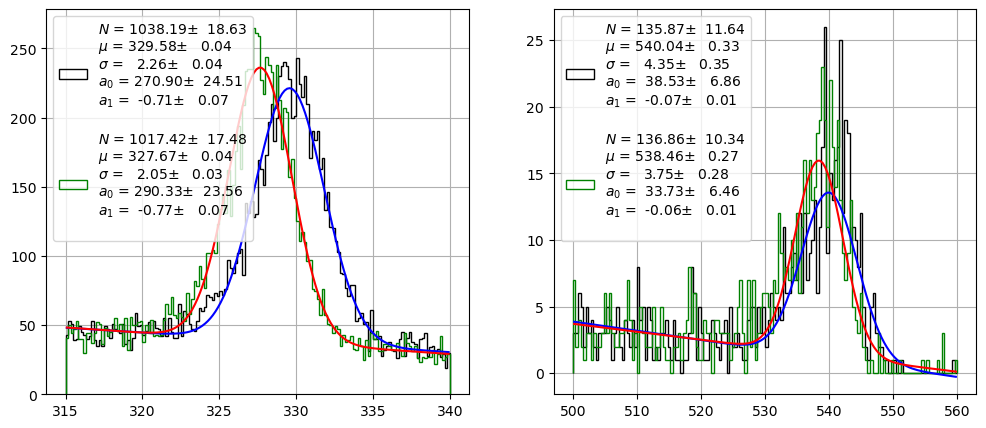

In [64]:
cv = pltext.canvas(2, 2);
cv(1)
xsel = gmax.cluster == 0
factor = 1e-3
sfun = 'gaus+Polynomial.1'
pltext.hfit(1e-3*esum.Ec_sum      , 150, fun = sfun, range = (315, 340));
pltext.hfit(1e-3*gsum.Ec_sum[xsel], 150, fun = sfun, range = (315, 340));
cv(2)
pltext.hfit(1e-3*esum.Ec_sum      , 150, fun = sfun, range = (500, 560));
pltext.hfit(1e-3*gsum.Ec_sum[xsel], 150, fun = sfun, range = (500, 560));
print(235.5*2.05/327.67, 235.5*3.75/538.46)

In [61]:
print(235.5*2.05/327.67, 235.5*2.26/329.58)

1.4733573412274543 1.614873475332241


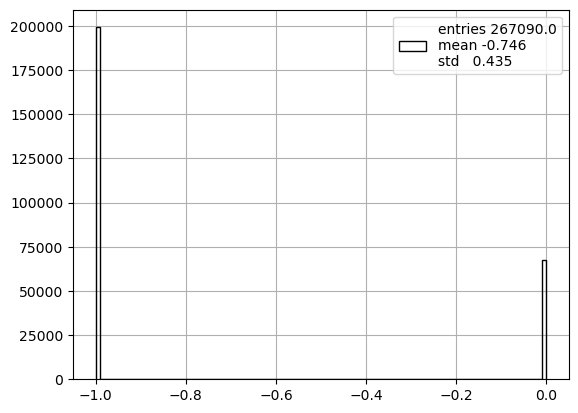

In [ ]:
dsts.groupby(['Z_min'])

In [ ]:
esum = dsts.groupby(['event']).sum()


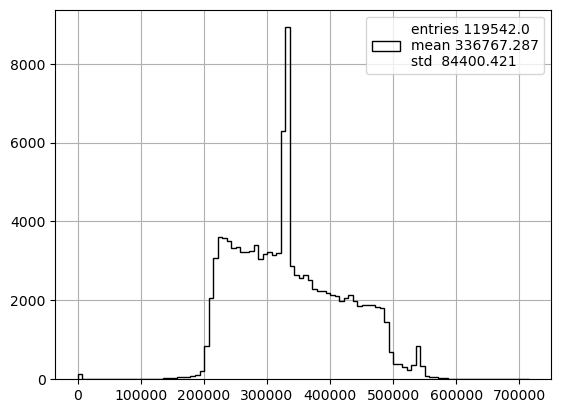

In [24]:
pltext.hist(esum.Ec_sum, 100);

In [ ]:
path_krmap = "/Users/hernando/work/investigacion/NEXT/data/NEXT100/data/krmaps/"
file_krmap = "GML_krmap_combined.map3d"
erange = (1.5, 1.8)
scale  = 1.

krmap_filename = path_krmap + file_krmap
data_filename  = path_data + filenames[0]
print(f'data file {data_filename}')
print(f'data file {krmap_filename}')
print('erange ', erange)

hits = he100.sophronia_extend(data_filename, krmap_filename, erange, save = True)

data file /Users/hernando/work/investigacion/NEXT/data/NEXT100/data/15604/sophronia_selected/hits/selected_hits_15604_ldc_1_0000.h5
data file /Users/hernando/work/investigacion/NEXT/data/NEXT100/data/15604/krmaps/GML_krmap_combined.map3d
erange  (1.5, 1.8)
Unexpected exception formatting exception. Falling back to standard exception


Traceback (most recent call last):
  File "/Users/hernando/miniconda/envs/IC-3.8-2022-04-13/lib/python3.8/site-packages/IPython/core/interactiveshell.py", line 3508, in run_code
    exec(code_obj, self.user_global_ns, self.user_ns)
  File "/var/folders/56/_pmdccc97ljb_l3v3s6gkrxm0000gn/T/ipykernel_74743/1541122387.py", line 12, in <module>
    hits = he100.sophronia_extend(data_filename, krmap_filename, erange, save = True)
  File "/Users/hernando/work/investigacion/NEXT/software/nextana/nana/he100/hefunc.py", line 107, in sophronia_extend
    corrector = get_corrector(krmap_filename)
  File "/Users/hernando/work/investigacion/NEXT/software/nextana/nana/he100/hefunc.py", line 71, in get_corrector
    krmap = pd.read_hdf(krmap_filename, "/krmap")
  File "/Users/hernando/miniconda/envs/IC-3.8-2022-04-13/lib/python3.8/site-packages/pandas/io/pytables.py", line 427, in read_hdf
    raise FileNotFoundError(f"File {path_or_buf} does not exist")
FileNotFoundError: File /Users/hernando/work/in

In [18]:
hits

,event,time,npeak,Xpeak,Ypeak,nsipm,X,Y,Xrms,Yrms,Z,Q,E,Qc,Ec,track_id,Ep,Ec0,cluster_id,cluster_id_in
0,2850,1.752754e+09,28,60.629311,63.621676,1,288.875,-263.725,0.0,0.0,568.031000,5.048163,1.891583,-1.0,2.057015,-1,-1.0,0.000010,-1,-1
1,2850,1.752754e+09,28,60.629311,63.621676,1,-420.425,229.875,0.0,0.0,571.823250,7.256641,0.291481,-1.0,0.000000,-1,-1.0,0.000003,-1,-1
2,2850,1.752754e+09,28,60.629311,63.621676,1,-65.775,106.975,0.0,0.0,571.823250,5.257367,0.211175,-1.0,0.214879,-1,-1.0,0.000001,-1,-1
3,2850,1.752754e+09,28,60.629311,63.621676,1,165.475,-217.575,0.0,0.0,571.823250,5.553848,0.223084,-1.0,0.226668,-1,-1.0,0.000001,-1,-1
4,2850,1.752754e+09,28,60.629311,63.621676,1,181.025,-155.375,0.0,0.0,571.823250,5.187352,0.208363,-1.0,0.210785,-1,-1.0,0.000001,-1,-1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3382816,3824206,1.752840e+09,28,73.845196,84.607359,1,-220.275,214.825,0.0,0.0,622.130625,5.567863,4.165986,-1.0,4.436614,-1,-1.0,0.000022,-1,-1
3382817,3824206,1.752840e+09,28,73.845196,84.607359,1,-112.425,29.225,0.0,0.0,625.861375,8.622585,4.589644,-1.0,4.820313,-1,-1.0,0.000024,-1,-1
3382818,3824206,1.752840e+09,28,73.845196,84.607359,1,42.075,338.225,0.0,0.0,625.861375,5.996884,3.192031,-1.0,3.382642,-1,-1.0,0.000017,-1,-1
3382819,3824206,1.752840e+09,28,73.845196,84.607359,1,-265.925,368.825,0.0,0.0,630.088875,6.686023,1.516247,-1.0,1.991286,-1,-1.0,0.000010,-1,-1


In [25]:
esum = hits.groupby(['event'], as_index = False).sum()

In [9]:
#kdst = load_dsts(filenames, "DST", "Events")
#hits  = load_dsts(filenames, "RECO", "Events")

In [10]:
def label_hits(df):
    """ label hits as scatter hits (-1) or hit a cluster (0, 1, 2, ...)
            label is stored as the column 'cluster_id' in the DF
        label hits as in the same z-range of a given cluster 
            i.e. -1 if out of any cluster, 0 in the same z-range of cluster 0, 
            if a hits is in the same z-range of several cluster gets the label of the cluster with the lower index
            label is stored as the column 'cluster_id_in' in the DF
    """ 
    df = label_hits_(df)
    df = label_hits_in_(df)
    return df

def label_hits_(df, scale = (14.55, 15.55, 3.7), eps = 2.3, max_clusters = 5):
    coors = df[['X', 'Y', 'Z']].to_numpy()
        
    coors[:, :2] /= scale[0]
    coors[:, 2]  /= scale[2]
        
    labels = DBSCAN(eps = eps, min_samples = max_clusters).fit_predict(coors)

    df['cluster_id'] = labels
    return df

def label_hits_in_(df):
    cluster_id = df.cluster_id.values
    zs = df.Z.values
    cluster_id_in = -1 * np.ones(len(cluster_id), int)
    df['cluster_id_in'] = -1
    for id in np.arange(max(cluster_id), -1, -1):
        xsel = cluster_id == id
        zmin, zmax = np.min(zs[xsel]), np.max(zs[xsel])
        ysel = ut.in_range(zs, (zmin, zmax))
        cluster_id_in[ysel] = id
    df['cluster_id_in'] = cluster_id_in
    return df
    

### Hit processing functions
Define clustering (`label_hits`), energy correction (`hits_corr`),
and scatter energy estimation (`esum_scatter_out_hits`) functions.

In [11]:
run = False
if (run):
    for file in filenames:
        hits  = load_dst(file, "RECO", "Events")
        hits_ext = hits.groupby(['event']).apply(label_hits)
        hits_ext = hits_ext.reset_index(drop = True)
        ofile = file.replace('.h5', '_ext.h5')
        print(ofile)
        hits_ext.to_hdf(ofile, 'hits', mode = 'w')

In [18]:
from scipy.interpolate import griddata

pathdata = "/Users/hernando/work/investigacion/NEXT/data/NEXT100/data/15604/krmaps/"

krmap = pd.read_hdf(pathdata + "GML_krmap_combined.map3d", "/krmap")
meta  = pd.read_hdf(pathdata + "GML_krmap_combined.map3d", "/mapmeta")

def get_corr(krmap, meta):
    dtxy_map   = krmap.loc[:, list("zxy")].values
    factor_map = krmap.factor.values
    def corr(dt, x, y, method="nearest"):
        dtxy_data   = np.stack([dt, x, y], axis=1)
        factor_data = griddata(dtxy_map, factor_map, dtxy_data, method=method)
        return factor_data
    return corr

corrector = get_corr(krmap, meta)

In [38]:
def hits_corr(hits):
    Ec  = hits.E.values * corrector(hits.Z.values, hits.X.values, hits.Y.values)
    return Ec

In [53]:
#ifiles = [ifile.replace('.h5', '_ext.h5') for ifile in filenames]
print(filenames)
prepare_de = False 
if (prepare_de):
    dsts = [pd.read_hdf(ifile, 'hits') for ifile in filenames]
    hits = pd.concat(dsts, ignore_index = True)

    hsum = hits.groupby('event', as_index = False).sum()
    derange = (1.500, 1.800)
    sel_de = ut.in_range(hsum.Ec.values, derange)
    events_de = hsum.event[sel_de].values

    hits_de = hits[np.isin(hits.event.values, events_de)]

    Ec = hits_corr(hits_de)

    factor = 1.672/329172.919

    hits_de['Ec0'] = hits_de.Ec.values.copy()
    hits_de['Ec']  = 1e3 * factor * Ec

    hits_de.to_hdf(filenames[0].replace('_ext.h5', '_dec.h5'), 'hits', mode = 'w')

hits_de = pd.read_hdf(filenames[0].replace('_ext.h5', '_dec.h5'), 'hits')
esum = hits_de.groupby(['event']).sum()

['/Users/hernando/work/investigacion/NEXT/data/NEXT100/data/15604/sophronia_selected/hits//selected_hits_15604_ldc_1_0000_ext.h5', '/Users/hernando/work/investigacion/NEXT/data/NEXT100/data/15604/sophronia_selected/hits//selected_hits_15604_ldc_2_0000_ext.h5', '/Users/hernando/work/investigacion/NEXT/data/NEXT100/data/15604/sophronia_selected/hits//selected_hits_15604_ldc_3_0000_ext.h5', '/Users/hernando/work/investigacion/NEXT/data/NEXT100/data/15604/sophronia_selected/hits//selected_hits_15604_ldc_4_0000_ext.h5', '/Users/hernando/work/investigacion/NEXT/data/NEXT100/data/15604/sophronia_selected/hits//selected_hits_15604_ldc_5_0000_ext.h5', '/Users/hernando/work/investigacion/NEXT/data/NEXT100/data/15604/sophronia_selected/hits//selected_hits_15604_ldc_6_0000_ext.h5', '/Users/hernando/work/investigacion/NEXT/data/NEXT100/data/15604/sophronia_selected/hits//selected_hits_15604_ldc_7_0000_ext.h5']


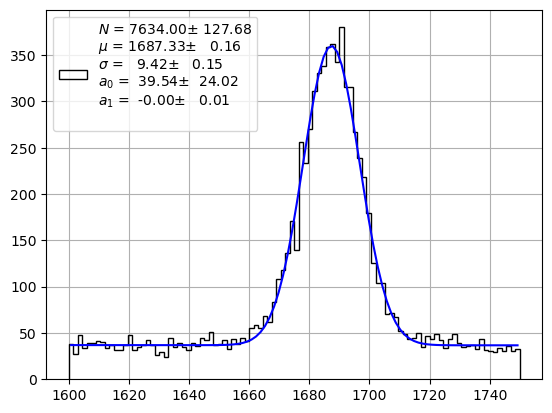

In [54]:
sfun = 'gaus+Polynomial.1'
pltext.hfit(esum.Ec, 100, fun = sfun, range = (1e3*1.6, 1e3*1.75));

In [55]:
emax = hits_de.groupby(['event']).max()

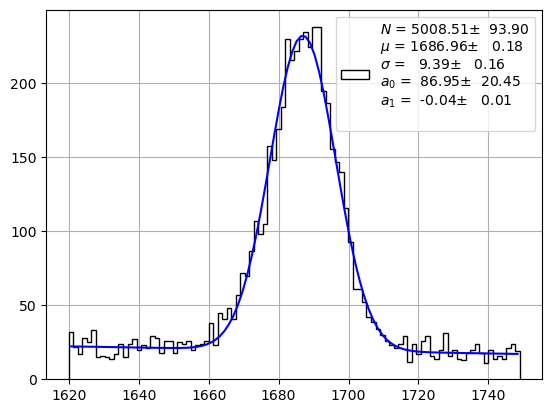

In [66]:
pltext.hfit(esum.Ec[emax.cluster_id == 0], 100, fun = sfun, range = (1620., 1749));

In [ ]:
### HERE
### remove the energy of the scatter out hits 

def esum_scatter_out_hits(df):
    sel = df.cluster_id_in <= 0
    if (sum(sel) <= 0): return 0.
    esum = np.sum(df[sel].Ec)
    return esum

In [69]:
eout = hits_de.groupby(['event']).apply(esum_scatter_out_hits)

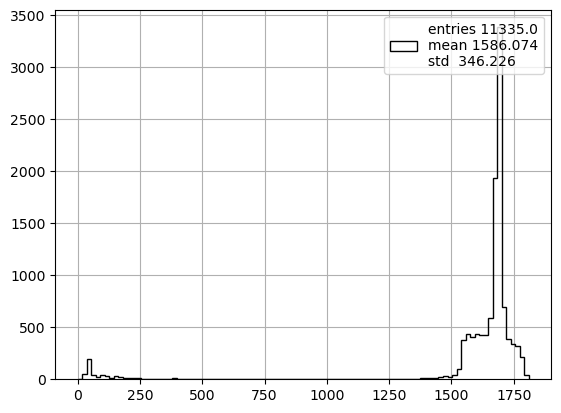

In [70]:
pltext.hist(eout, 100);

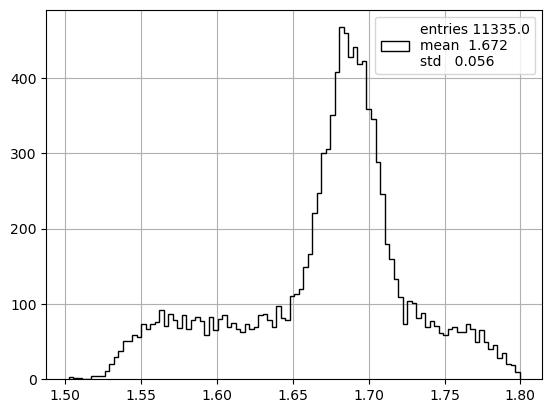

In [14]:
hsum = hits.groupby('event', as_index = False).sum()
derange = (1.500, 1.800)
sel_de = ut.in_range(hsum.Ec.values, derange)
events_de = hsum.event[sel_de].values

pltext.hist(hsum.Ec[sel_de], 100);

In [15]:
hits_de = hits[np.isin(hits.event.values, events_de)]

In [16]:
hits_de.to_hdf(filenames[0].replace('_ext.h5', '_de.h5'), 'hits', mode = 'w')

In [17]:
hits = None
hits_de = pd.read_hdf(filenames[0].replace('_ext.h5', '_de.h5'), 'hits')

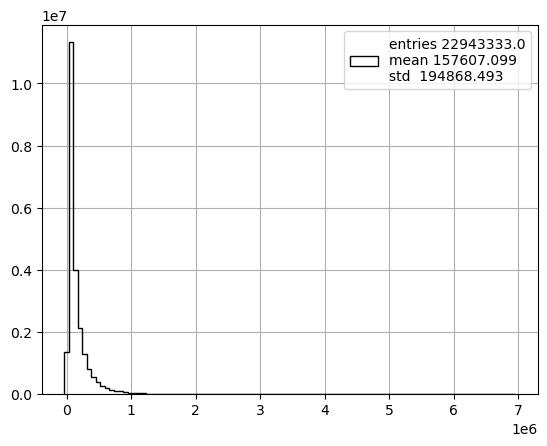

In [25]:
pltext.hist(1e3*hits_de.E, 100);

In [39]:
Ec = hits_corr(hits_de)

In [ ]:
hits_de['Ec0'] = hits_de.Ec.values.copy()
hits_de['Ec']  = Ec

In [41]:
esum = hits_de.groupby(['event']).sum()

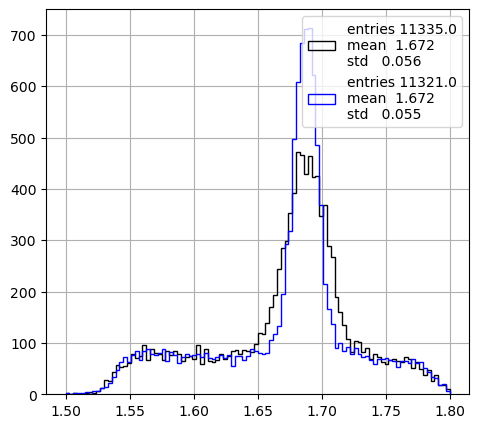

In [44]:
cv = pltext.canvas(2, 2)
factor = 1.672/329172.919
cv(1); pltext.hist(esum.Ec0, 100, (1.5, 1.8));
cv(1); pltext.hist(factor*esum.Ec, 100, (1.5, 1.8));

In [49]:
#hits_de['Ec'] = 1e3 * factor * hits_de['Ec'].values
hits_de.to_hdf(filenames[0].replace('_ext.h5', '_dec.h5'), 'hits', mode = 'w')

In [50]:
hits_de = pd.read_hdf(filenames[0].replace('_ext.h5', '_dec.h5'), 'hits')

In [51]:
esum = hits_de.groupby(['event']).sum()

In [ ]:
hits_de['Ec0'] = hits_de['E'].values
hits_de['Ec'] = hits.E * corrector(hits.X, hits.Y, hits.Z)

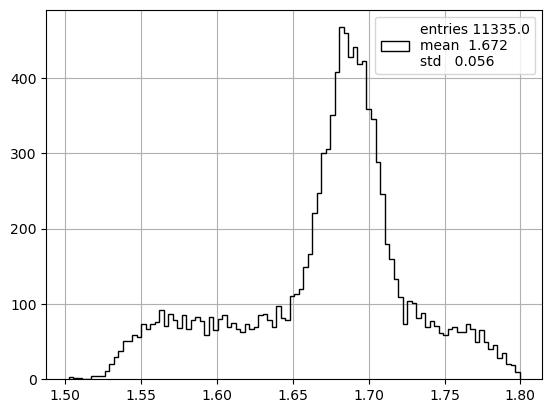

In [14]:
esum = hits_de.groupby(['event'], as_index = False).sum()
pltext.hist(esum.Ec, 100);

In [ ]:
def hits_ext(hits):

    Ec = hits.E * corrector(hits.Z, hits.X, hits.Y)

    


In [ ]:
def df_event_summary_stats(hits):
    hits_  = hits.groupby(['event'],  as_index = False)
    hsum   = hits_.sum()
    hmin   = hits_.min()
    hmax   = hits_.max()
    hcount = hits_.count()
    hmean  = hits_.mean()

    df = {'event' : hsum.event,
          'X' : hmean.X, 'Y' : hmean.Y, 'Z' : hmean.Z, 
          'R' : np.sqrt(hmean.X**2 + hmean.Y**2),
          'Xmin' : hmin.Z, 'Xmax' : hmax.Z,
          'Ymin' : hmin.Z, 'Ymax' : hmax.Z,
          'Zmin' : hmin.Z, 'Zmax' : hmax.Z,
          'Ec'   : hsum.Ec, 'nhits' : hcount.Ec}
    
    return pd.DataFrame(df)

In [ ]:
desum = df_event_summary_stats(hits_de)

In [21]:
sel_in = hits_de.cluster_id_in >= 0
hits_de_in = hits_de[sel_in]

In [24]:
desum_in = df_event_summary_stats(hits_de_in)

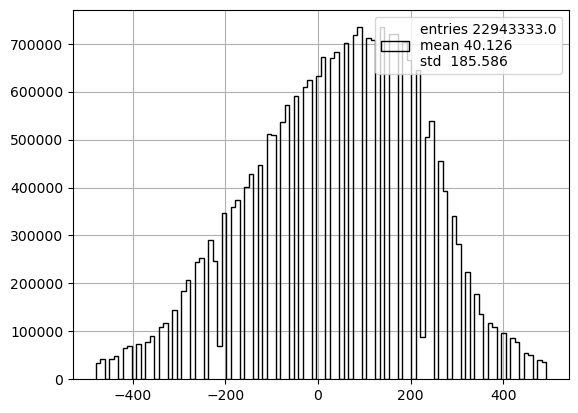

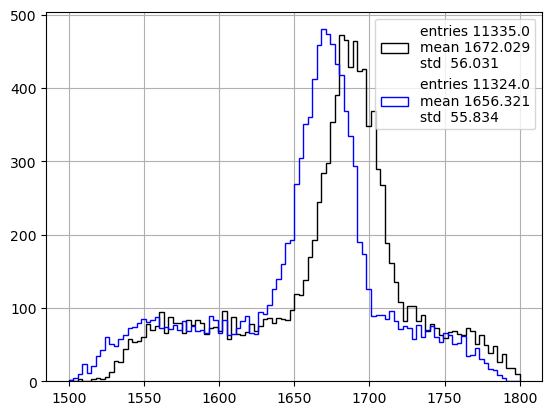

In [26]:
pltext.hist(1e3*desum.Ec[desum.R < 400], 100, (1500, 1800));
pltext.hist(1e3*desum_in.Ec[desum_in.R < 400], 100, (1500, 1800));

In [2]:
hsum = df_event_summary_stats(hits[hits.event < 100])

NameError: name 'df_event_summary_stats' is not defined

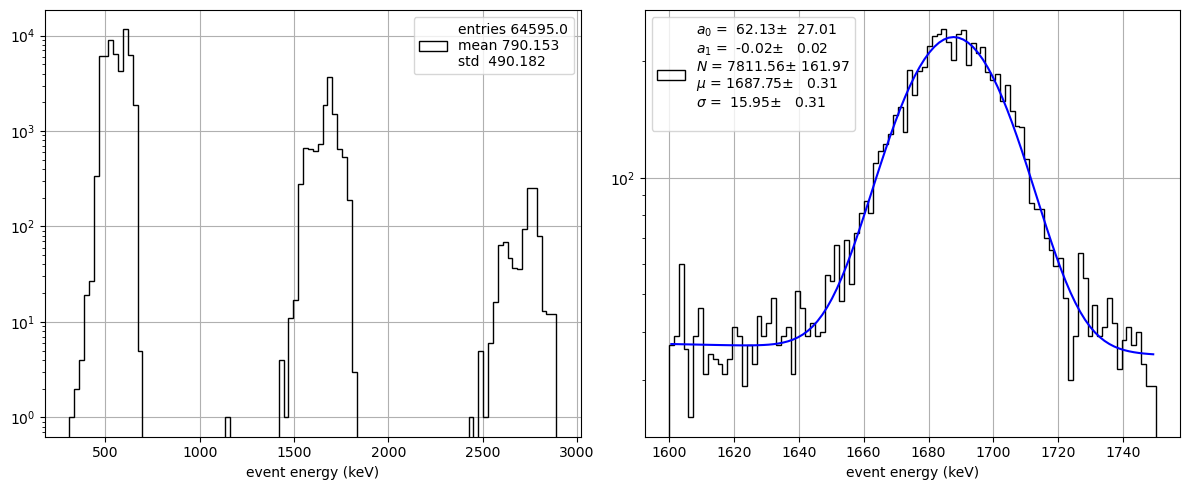

In [33]:
derange = (1600, 1750)

sfun = 'Polynomial.1+gaus'
cv = pltext.canvas(2, 2)
cv(1); pltext.hist(1e3*hsum.Ec, 100); plt.xlabel('event energy (keV)'); plt.yscale('log');
cv(2); pltext.hfit(1e3*hsum.Ec, 100, fun = sfun, range = derange); 
plt.xlabel('event energy (keV)'); plt.yscale('log');
plt.tight_layout();
plt.tight_layout();

In [38]:
hmax.columns

Index(['event', 'time', 'npeak', 'Xpeak', 'Ypeak', 'nsipm', 'X', 'Y', 'Xrms',
       'Yrms', 'Z', 'Q', 'E', 'Qc', 'Ec', 'track_id', 'Ep', 'cluster_id',
       'cluster_id_in'],
      dtype='object')

In [61]:
def fwhm(sigma, mu):
    return 235.5 * sigma/mu

### Select DE events
Select double-escape events in 1600-1750 keV window.
Analyze scatter vs cluster hit distributions and energy fractions.

**Note**: Below contains exploratory and duplicate cells from development.

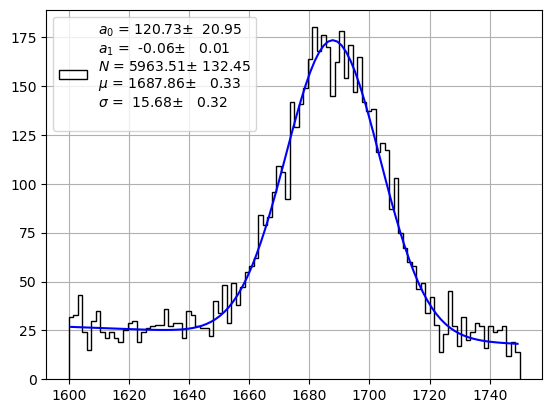

In [ ]:
sel_de    = ut.in_range(1e3*hsum.Ec, derange)
events_de = hsum[sel_de].event.values
pltext.hfit(1e3*hsum[sel_de].Ec, 100, fun = sfun, range = derange);

hits_de = hits[np.isin(hits.event.values, events_de)]



In [31]:
from scipy.interpolate import griddata

pathdata = "/Users/hernando/work/investigacion/NEXT/data/NEXT100/data/15604/krmaps/"

krmap = pd.read_hdf(pathdata + "GML_krmap_combined.map3d", "/krmap")
meta  = pd.read_hdf(pathdata + "GML_krmap_combined.map3d", "/mapmeta")

def get_corr(krmap, meta):
    dtxy_map   = krmap.loc[:, list("zxy")].values
    factor_map = krmap.factor.values
    def corr(dt, x, y, method="nearest"):
        dtxy_data   = np.stack([dt, x, y], axis=1)
        factor_data = griddata(dtxy_map, factor_map, dtxy_data, method=method)
        return factor_data
    return corr

corrector = get_corr(krmap, meta)
#corrected_energy = data.E * corrector(data.Z, data.X, data.Y)

In [ ]:
Ec = hits.E * corrector(hits.Z, data.X, data.Y)

In [17]:
#ifiles = [ifile.replace('.h5', '_ext.h5') for ifile in filenames]
dsts = [pd.read_hdf(ifile, 'hits') for ifile in filenames]
hits = pd.concat(dsts, ignore_index = True)

In [ ]:
#hits = pd.concat(dsts, ignore_index=True)

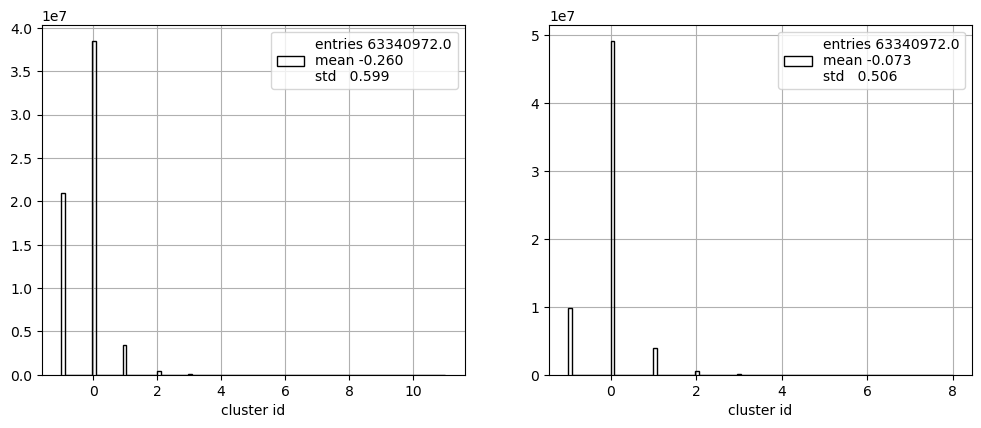

In [19]:
cv = pltext.canvas(4, 2)
cv(1); pltext.hist(hits.cluster_id, 100); plt.xlabel('cluster id');
cv(2); pltext.hist(hits.cluster_id_in, 100); plt.xlabel('cluster id');

In [20]:
hmax = hits.groupby(['event']).max()
hsum = hits.groupby(['event']).sum()

In [21]:
csum = hits[hits.cluster_id_in >= 0].groupby('event').sum()

In [43]:
esum = hits.groupby(['event'], as_index = False).sum()

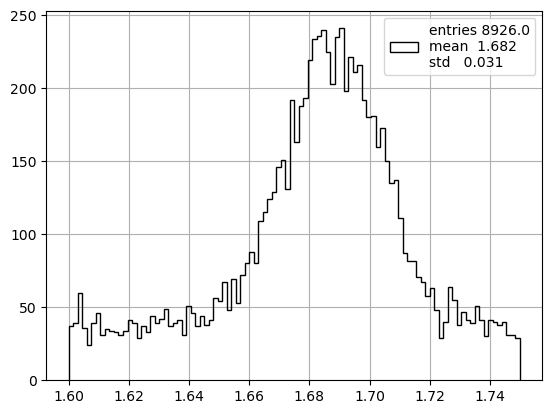

In [51]:
sel_de  = ut.in_range(esum.Ec, (1.6, 1.75))
evts_de = esum[sel_de]['event'].values
pltext.hist(esum.Ec[sel_de], 100);
sel_hitsde = np.isin(hits.event.values, evts_de)

In [52]:
hits_de = hits[sel_hitsde]

In [ ]:
sel_hitsde_iso     = hits_de.cluster_id < 0
sel_hitsde_cls     = hits_de.cluster_id >= 0
sel_hitsde_iso_in  = np.logical_and(hits_de.cluster_id_in >= 0, sel_hitsde_iso)
sel_hitsde_iso_out = np.logical_and(hits_de.cluster_id_in < 0 , sel_hitsde_iso)

Text(0.5, 0, 'hit cluster id')

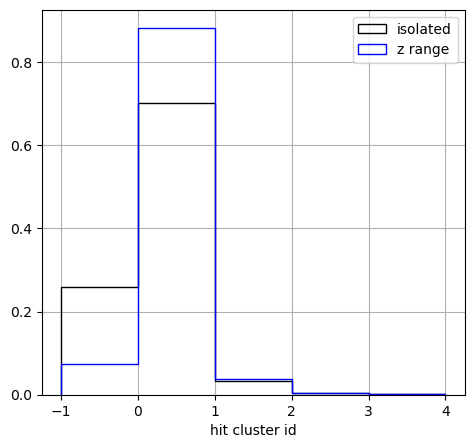

In [89]:
cv = pltext.canvas(2, 2)
cv(1); pltext.hist(hits_de.cluster_id, 5, (-1, 4), label = 'isolated', density = True, stats = False)
cv(1); pltext.hist(hits_de.cluster_id_in, 5, (-1, 4), label = 'z range', density = True, stats = False);
plt.xlabel('hit cluster id')

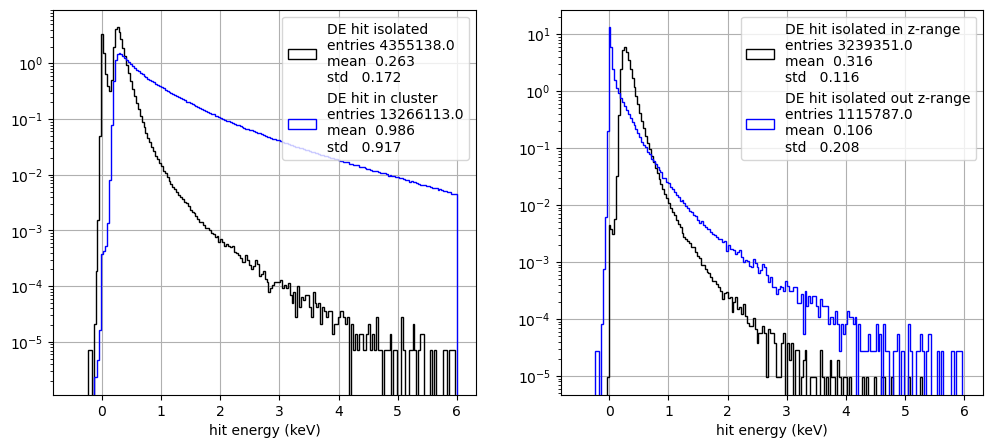

In [109]:
cv = pltext.canvas(2, 2)
cv(1);
pltext.hist(1000.*hits_de[sel_hitsde_iso].Ec, 200, range = (-0.5, 6), label = 'DE hit isolated', density = True)
pltext.hist(1000.*hits_de[sel_hitsde_cls].Ec, 200, range = (-0.5, 6), label = 'DE hit in cluster', density = True);
plt.xlabel('hit energy (keV)'); plt.legend(); plt.yscale('log');
cv(2);
pltext.hist(1000.*hits_de[sel_hitsde_iso_in].Ec, 200, range = (-0.5, 6), label = 'DE hit isolated in z-range', density = True)
pltext.hist(1000.*hits_de[sel_hitsde_iso_out].Ec, 200, range = (-0.5,6), label = 'DE hit isolated out z-range', density = True);
plt.xlabel('hit energy (keV)'); plt.legend(); plt.yscale('log');


In [118]:
edetot_   = hits_de.groupby(['event']).sum()
edecls_   = hits_de[sel_hitsde_cls].groupby(['event']).sum()
eiso_     = hits_de[sel_hitsde_iso].groupby(['event']).sum()
hiso_     = hits_de[sel_hitsde_iso].groupby(['event']).count()
eisoin_   = hits_de[sel_hitsde_iso_in].groupby(['event']).sum()
hisoin_   = hits_de[sel_hitsde_iso_in].groupby(['event']).count()
eisoout_  = hits_de[sel_hitsde_iso_out].groupby(['event']).sum()
hisoout_  = hits_de[sel_hitsde_iso_out].groupby(['event']).count()

desum_   = hits_de[hits_de.cluster_id_in == 0].groupby(['event']).sum()
demin_  = hits_de[hits_de.cluster_id_in == 0].groupby(['event']).min()
demax_  = hits_de[hits_de.cluster_id_in == 0].groupby(['event']).max()
demean_ = hits_de[hits_de.cluster_id_in == 0].groupby(['event']).mean()

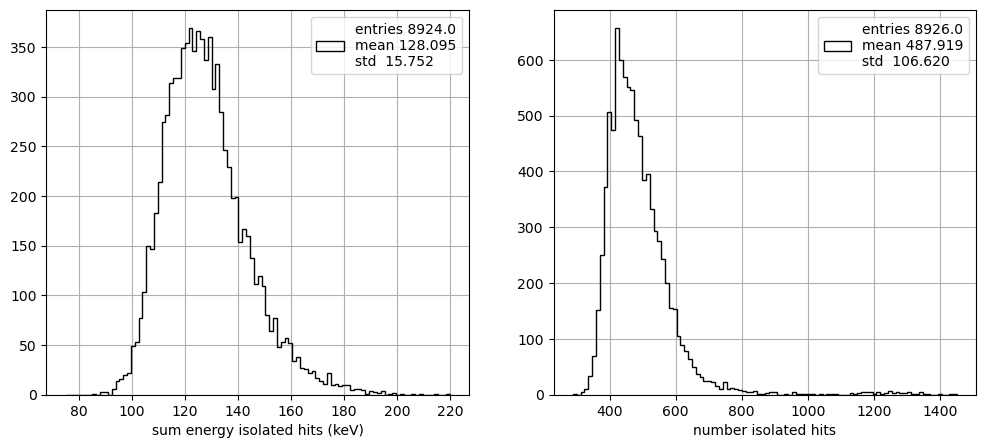

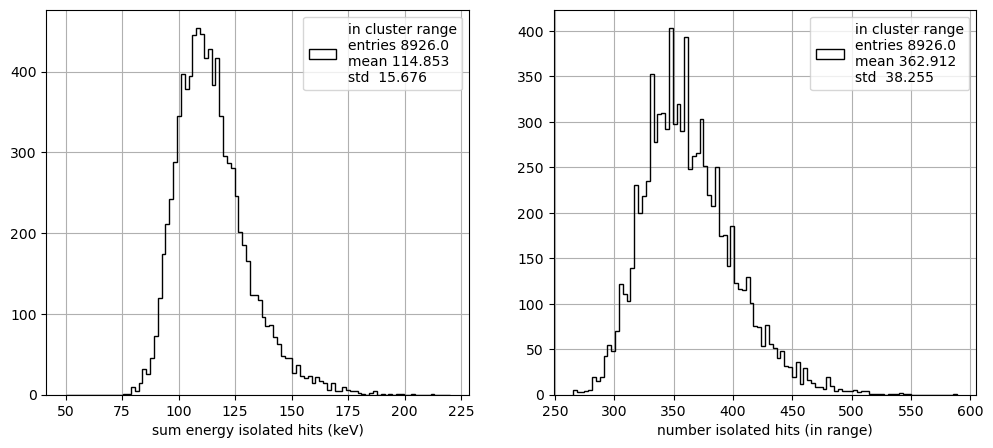

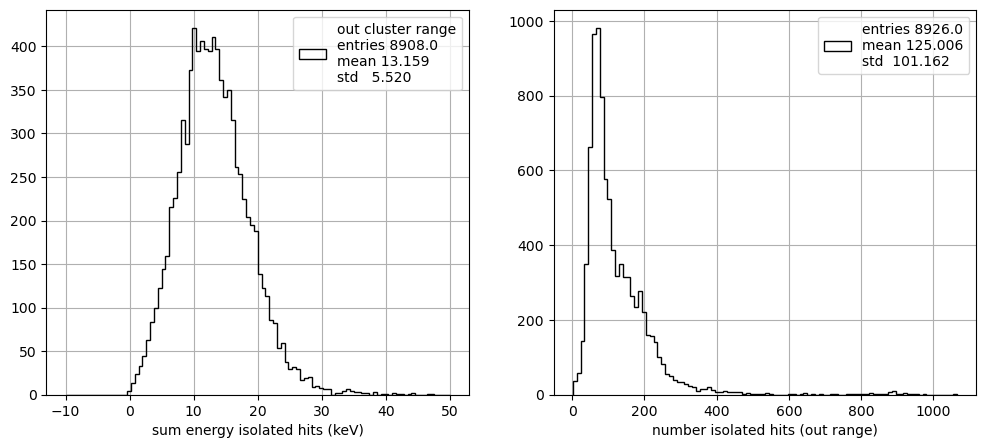

In [104]:
cv = pltext.canvas(2, 2)
cv(1); pltext.hist(1000.*eiso_.Ec, 100, (75, 220));
plt.xlabel('sum energy isolated hits (keV)')
cv(2); pltext.hist(hiso_.Ec, 100); 
plt.xlabel('number isolated hits')

cv = pltext.canvas(2, 2)
cv(1); pltext.hist(1000.*eisoin_.Ec, 100, (50, 220), label = 'in cluster range');
plt.xlabel('sum energy isolated hits (keV)'); plt.legend();
cv(2); pltext.hist(hisoin_.Ec, 100, label = 'in cluster range'); plt.xlabel('number isolated hits (in range)')

cv = pltext.canvas(2, 2)
cv(1); pltext.hist(1000.*eisoout_.Ec, 100, (-10, 50), label = 'out cluster range');
plt.xlabel('sum energy isolated hits (keV)');  plt.legend();
cv(2); pltext.hist(hisoout_.Ec, 100); plt.xlabel('number isolated hits (out range)');

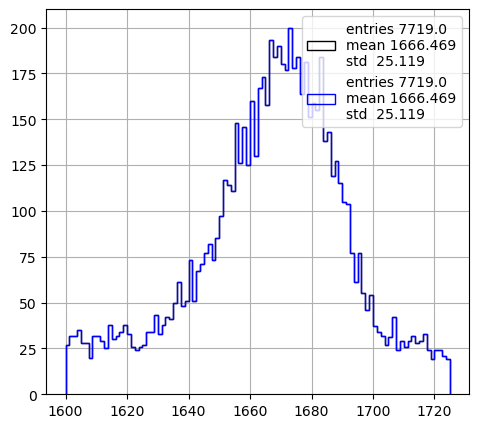

In [130]:
cv = pltext.canvas(2, 2)
xsel = demax_.cluster_id_in == 0
cv(1); pltext.hist(1000.*desum_.Ec[xsel], 100, (1600, 1725));
cv(1); pltext.hist(1000.*desum_.Ec, 100, (1600, 1725));



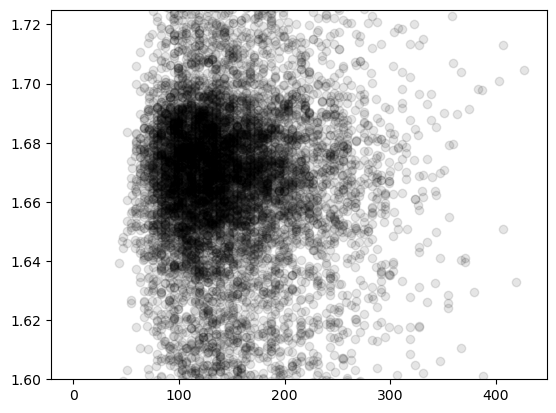

In [135]:
plt.scatter(demax_.Z - demin_.Z, desum_.Ec, alpha = 0.1)
plt.ylim((1.60, 1.725));

ZeroDivisionError: Weights sum to zero, can't be normalized

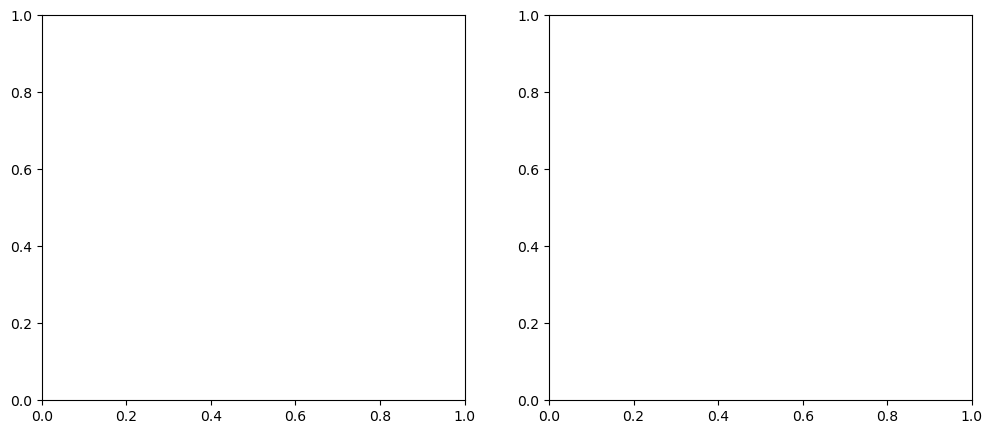

In [119]:
#ec_ = eiso_.Ec.values
#ec_[np.isnan(ec_)] = -0.0001

cv = pltext.canvas(2, 2)
cv(1);
#pltext.hist(1000.*ec_, 200, range = (-0.5, 1), label = 'DE hits isolated', density = True)
#plt.xlabel('sum hit energy (keV)'); plt.legend(); plt.yscale('log');
cv(2);
pltext.hist(1000.*eisoin_.Ec, 200, range = (-0.5, 10), label = 'DE hits isolated in z-range', density = True)
pltext.hist(1000.*eisoout_.Ec, 200, range = (-0.5,10), label = 'DE hits isolated out z-range', density = True);
plt.xlabel('sum hit energy (keV)'); plt.legend(); plt.yscale('log');

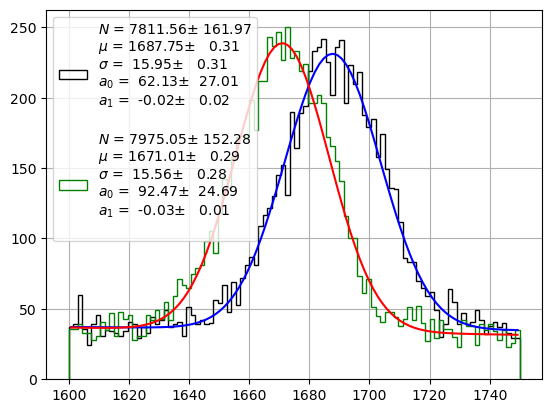

In [24]:
pltext.hfit(1000 * hsum.Ec, 100, fun = 'gaus+Polynomial.1', range = (1600, 1750));
pltext.hfit(1000 * csum.Ec, 100, fun = 'gaus+Polynomial.1', range = (1600, 1750));

In [ ]:
csum = hits[hits.group_id >= 0].groupby('event').sum()

In [ ]:
csum2 = hits[hits.group_id_in == 0].groupby('event').sum()

In [13]:
esum = hits.groupby("event").sum()

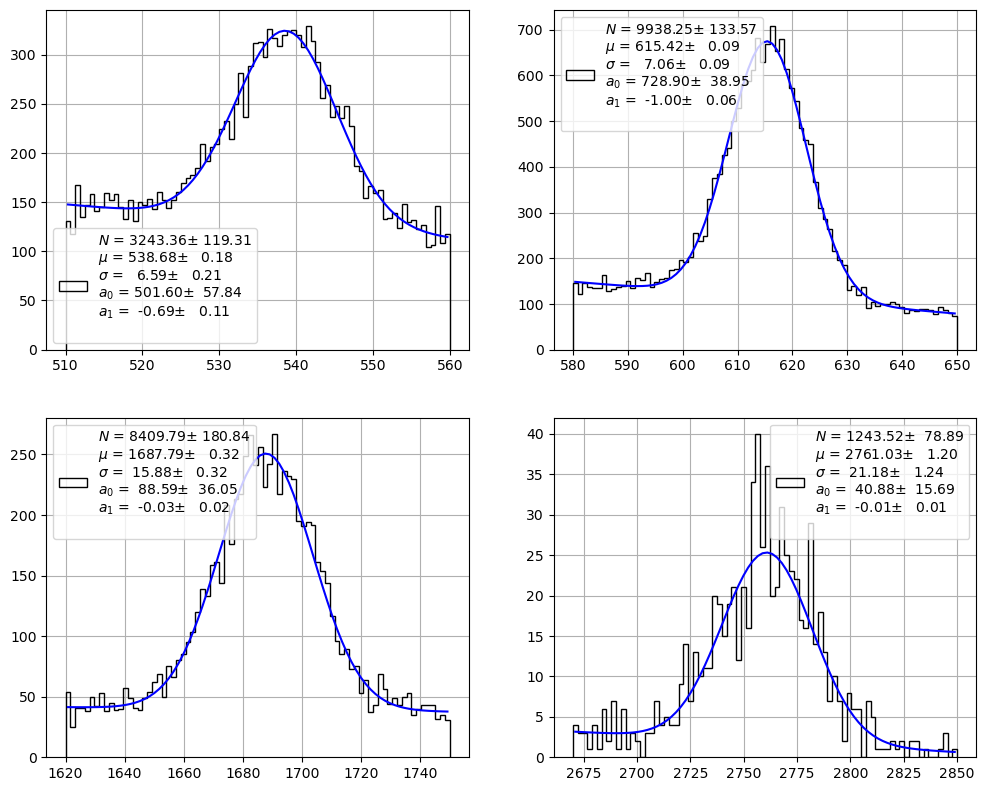

In [14]:
pranges  = [(510, 560), (580, 650), (1620, 1750), (2670, 2850)]
energy = esum.Ec
cv = pltext.canvas(6, 2)
p0 = np.array((1e2, 0.53, 0.05))
#for i, irange in enumerate(peak_ranges_d):
i = 5
for i, irange in enumerate(pranges):
    cv(i+1); pltext.hfit(1e3*energy, fun = 'gaus+Polynomial.1', bins = 80, range = irange);


In [15]:
hits

,event,time,npeak,Xpeak,Ypeak,nsipm,X,Y,Xrms,Yrms,Z,Q,E,Qc,Ec,track_id,Ep
0,1002,1.752754e+09,29,-13.72357,-22.474468,1,-312.575,29.725,0.0,0.0,819.497000,5.284064,0.253553,-1.0,1.343636e-06,-1,-1.0
1,1002,1.752754e+09,29,-13.72357,-22.474468,1,-189.175,-464.375,0.0,0.0,819.497000,5.915947,0.283873,-1.0,NaN,-1,-1.0
2,1002,1.752754e+09,29,-13.72357,-22.474468,1,-19.125,245.925,0.0,0.0,819.497000,5.733700,0.275128,-1.0,1.467139e-06,-1,-1.0
3,1002,1.752754e+09,29,-13.72357,-22.474468,1,458.925,-124.775,0.0,0.0,819.497000,6.535708,0.313612,-1.0,2.386047e-06,-1,-1.0
4,1002,1.752754e+09,29,-13.72357,-22.474468,1,412.275,-1.375,0.0,0.0,819.497000,6.571945,0.315351,-1.0,1.803902e-06,-1,-1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
63340967,3825003,1.752840e+09,28,-50.09021,70.791589,1,-112.425,-109.725,0.0,0.0,272.440375,5.038843,-0.186281,-1.0,-9.611699e-07,-1,-1.0
63340968,3825003,1.752840e+09,28,-50.09021,70.791589,1,-19.125,75.875,0.0,0.0,272.440375,5.707632,-0.211006,-1.0,-1.063815e-06,-1,-1.0
63340969,3825003,1.752840e+09,28,-50.09021,70.791589,1,42.075,-479.925,0.0,0.0,272.440375,6.375054,-0.235680,-1.0,-2.185854e-06,-1,-1.0
63340970,3825003,1.752840e+09,28,-50.09021,70.791589,1,73.175,-31.975,0.0,0.0,272.440375,5.156217,-0.190620,-1.0,-9.458313e-07,-1,-1.0


In [102]:
def label_hits(df, scale = (14.55, 15.55, 3.7), eps = 2.3, max_clusters = 5):
    coors = df[['X', 'Y', 'Z']].to_numpy()
        
    coors[:, :2] /= scale[0]
    coors[:, 2]  /= scale[2]
        
    labels = DBSCAN(eps = eps, min_samples = max_clusters).fit_predict(coors)

    df['cluster_id'] = labels
    return df
#    return labels


In [94]:
hits[hits.event < 100]

,event,time,npeak,Xpeak,Ypeak,nsipm,X,Y,Xrms,Yrms,Z,Q,E,Qc,Ec,track_id,Ep,cluster_id
9206038,86,1.752754e+09,17,-11.914796,75.388871,1,-126.975,414.975,0.0,0.0,499.820375,5.012531,37.486379,-1.0,0.000232,-1,-1.0,0
9206039,86,1.752754e+09,17,-11.914796,75.388871,1,42.075,137.075,0.0,0.0,499.820375,5.314590,39.745331,-1.0,0.000204,-1,-1.0,0
9206040,86,1.752754e+09,17,-11.914796,75.388871,1,335.525,122.025,0.0,0.0,499.820375,5.317106,39.764153,-1.0,0.000213,-1,-1.0,0
9206041,86,1.752754e+09,17,-11.914796,75.388871,1,366.625,137.575,0.0,0.0,499.820375,5.557271,41.560233,-1.0,0.000230,-1,-1.0,0
9206042,86,1.752754e+09,17,-11.914796,75.388871,1,-281.475,-309.375,0.0,0.0,507.043000,9.449904,258.692389,-1.0,0.001535,-1,-1.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
36115963,12,1.752754e+09,24,13.996462,126.495757,1,335.525,-279.275,0.0,0.0,988.311875,7.733692,0.256871,-1.0,0.000002,-1,-1.0,0
36115964,12,1.752754e+09,24,13.996462,126.495757,1,335.525,153.125,0.0,0.0,988.311875,6.836868,0.227084,-1.0,0.000001,-1,-1.0,0
36115965,12,1.752754e+09,24,13.996462,126.495757,1,-158.075,-356.525,0.0,0.0,990.892000,5.269515,-2.229028,-1.0,-0.000013,-1,-1.0,0
36115966,12,1.752754e+09,24,13.996462,126.495757,1,57.625,-263.225,0.0,0.0,990.892000,6.668149,-2.820656,-1.0,-0.000015,-1,-1.0,0


In [103]:
hits_ext = hits[hits.event < 100].groupby(['event']).apply(label_hits)

In [104]:
np.unique(hits_ext.cluster_id)

array([-1,  0,  1,  2])

In [ ]:
np.arange(10).reverse()

In [105]:
def label_hits_in_cluster_zrange(df):
    cluster_id = df.cluster_id
    zs = df.Z.values
    df['in_cluster_id'] = -1
    ids = np.unique(cluster_id[cluster_id >0])
    for id in ids.reverse():
        xsel = cluster_id == id
        zmin, zmax = np.min(zs[xsel]), np.max(zs[xsel])
        ysel = ut.in_range(zs, zmin, zmax)
        df[ysel].in_cluster_id = id
    return df
    



In [ ]:
hits_ext = hits.groupby(['event']).apply(label_hits)
hits_ext = hits_ext.reset_index(drop = True)

In [107]:
hits_ext

,event,time,npeak,Xpeak,Ypeak,nsipm,X,Y,Xrms,Yrms,Z,Q,E,Qc,Ec,track_id,Ep,cluster_id
9206038,86,1.752754e+09,17,-11.914796,75.388871,1,-126.975,414.975,0.0,0.0,499.820375,5.012531,37.486379,-1.0,0.000232,-1,-1.0,-1
9206039,86,1.752754e+09,17,-11.914796,75.388871,1,42.075,137.075,0.0,0.0,499.820375,5.314590,39.745331,-1.0,0.000204,-1,-1.0,-1
9206040,86,1.752754e+09,17,-11.914796,75.388871,1,335.525,122.025,0.0,0.0,499.820375,5.317106,39.764153,-1.0,0.000213,-1,-1.0,-1
9206041,86,1.752754e+09,17,-11.914796,75.388871,1,366.625,137.575,0.0,0.0,499.820375,5.557271,41.560233,-1.0,0.000230,-1,-1.0,-1
9206042,86,1.752754e+09,17,-11.914796,75.388871,1,-281.475,-309.375,0.0,0.0,507.043000,9.449904,258.692389,-1.0,0.001535,-1,-1.0,-1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
36115963,12,1.752754e+09,24,13.996462,126.495757,1,335.525,-279.275,0.0,0.0,988.311875,7.733692,0.256871,-1.0,0.000002,-1,-1.0,-1
36115964,12,1.752754e+09,24,13.996462,126.495757,1,335.525,153.125,0.0,0.0,988.311875,6.836868,0.227084,-1.0,0.000001,-1,-1.0,-1
36115965,12,1.752754e+09,24,13.996462,126.495757,1,-158.075,-356.525,0.0,0.0,990.892000,5.269515,-2.229028,-1.0,-0.000013,-1,-1.0,-1
36115966,12,1.752754e+09,24,13.996462,126.495757,1,57.625,-263.225,0.0,0.0,990.892000,6.668149,-2.820656,-1.0,-0.000015,-1,-1.0,-1


In [106]:
hits_ext = hits_ext.groupby(['event']).apply(label_hits_in_cluster_zrange)

AttributeError: 'numpy.ndarray' object has no attribute 'reverse'

Index([], dtype='object')

In [85]:
hits

,event,time,npeak,Xpeak,Ypeak,nsipm,X,Y,Xrms,Yrms,Z,Q,E,Qc,Ec,track_id,Ep,cluster_id
0,1002,1.752754e+09,29,-13.72357,-22.474468,1,-312.575,29.725,0.0,0.0,819.497000,5.284064,0.253553,-1.0,1.343636e-06,-1,-1.0,0
1,1002,1.752754e+09,29,-13.72357,-22.474468,1,-189.175,-464.375,0.0,0.0,819.497000,5.915947,0.283873,-1.0,NaN,-1,-1.0,0
2,1002,1.752754e+09,29,-13.72357,-22.474468,1,-19.125,245.925,0.0,0.0,819.497000,5.733700,0.275128,-1.0,1.467139e-06,-1,-1.0,0
3,1002,1.752754e+09,29,-13.72357,-22.474468,1,458.925,-124.775,0.0,0.0,819.497000,6.535708,0.313612,-1.0,2.386047e-06,-1,-1.0,0
4,1002,1.752754e+09,29,-13.72357,-22.474468,1,412.275,-1.375,0.0,0.0,819.497000,6.571945,0.315351,-1.0,1.803902e-06,-1,-1.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
63340967,3825003,1.752840e+09,28,-50.09021,70.791589,1,-112.425,-109.725,0.0,0.0,272.440375,5.038843,-0.186281,-1.0,-9.611699e-07,-1,-1.0,0
63340968,3825003,1.752840e+09,28,-50.09021,70.791589,1,-19.125,75.875,0.0,0.0,272.440375,5.707632,-0.211006,-1.0,-1.063815e-06,-1,-1.0,0
63340969,3825003,1.752840e+09,28,-50.09021,70.791589,1,42.075,-479.925,0.0,0.0,272.440375,6.375054,-0.235680,-1.0,-2.185854e-06,-1,-1.0,0
63340970,3825003,1.752840e+09,28,-50.09021,70.791589,1,73.175,-31.975,0.0,0.0,272.440375,5.156217,-0.190620,-1.0,-9.458313e-07,-1,-1.0,0


In [75]:
hits['cluster_id'] = np.zeros(len(hits), int)

In [42]:
df = hits.groupby(['event'])
df.get_group(1002)

,event,time,npeak,Xpeak,Ypeak,nsipm,X,Y,Xrms,Yrms,Z,Q,E,Qc,Ec,track_id,Ep
0,1002,1.752754e+09,29,-13.72357,-22.474468,1,-312.575,29.725,0.0,0.0,819.497000,5.284064,0.253553,-1.0,1.343636e-06,-1,-1.0
1,1002,1.752754e+09,29,-13.72357,-22.474468,1,-189.175,-464.375,0.0,0.0,819.497000,5.915947,0.283873,-1.0,NaN,-1,-1.0
2,1002,1.752754e+09,29,-13.72357,-22.474468,1,-19.125,245.925,0.0,0.0,819.497000,5.733700,0.275128,-1.0,1.467139e-06,-1,-1.0
3,1002,1.752754e+09,29,-13.72357,-22.474468,1,458.925,-124.775,0.0,0.0,819.497000,6.535708,0.313612,-1.0,2.386047e-06,-1,-1.0
4,1002,1.752754e+09,29,-13.72357,-22.474468,1,412.275,-1.375,0.0,0.0,819.497000,6.571945,0.315351,-1.0,1.803902e-06,-1,-1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
703,1002,1.752754e+09,29,-13.72357,-22.474468,1,26.525,-94.175,0.0,0.0,1078.210125,6.014832,-0.189021,-1.0,-9.914047e-07,-1,-1.0
704,1002,1.752754e+09,29,-13.72357,-22.474468,1,134.375,-0.875,0.0,0.0,1078.210125,5.937361,-0.186586,-1.0,-9.951590e-07,-1,-1.0
705,1002,1.752754e+09,29,-13.72357,-22.474468,1,-173.625,-170.925,0.0,0.0,1082.931500,5.041929,0.680244,-1.0,3.579359e-06,-1,-1.0
706,1002,1.752754e+09,29,-13.72357,-22.474468,1,-112.425,230.375,0.0,0.0,1082.931500,5.696793,0.768596,-1.0,4.150973e-06,-1,-1.0


In [44]:
events = np.unique(hits['event'].values)
events

array([     12,      86,     122, ..., 3825123, 3825173, 3825205])

In [70]:
ievt = events[9]
print(ievt)
idf = hits[hits.event == ievt]
labels = label_hits(idf)

881


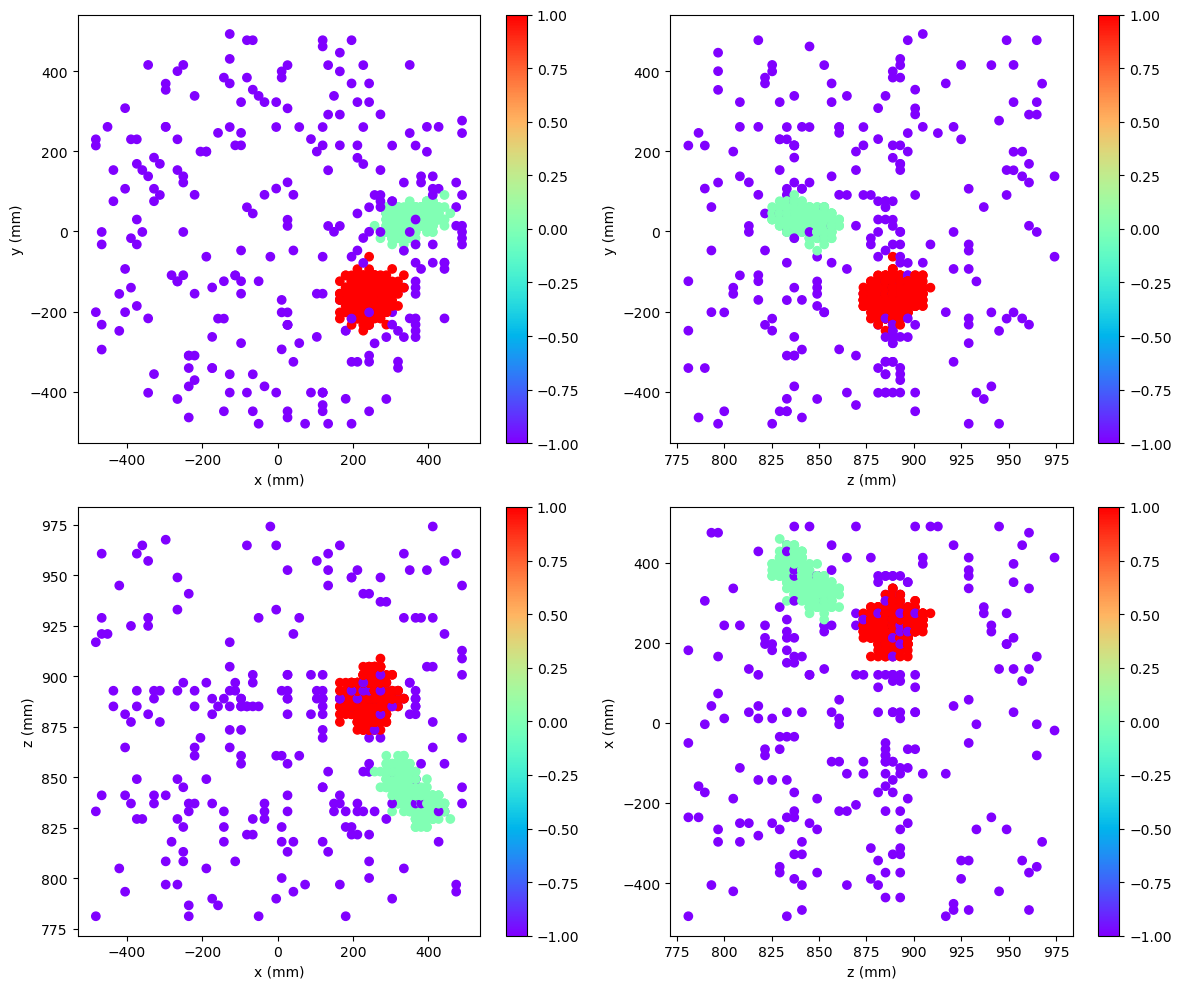

In [71]:
cv = pltext.canvas(4, 2)
cv(1); plt.scatter(idf.X, idf.Y, c = labels, alpha = 1); plt.colorbar(); plt.xlabel('x (mm)'); plt.ylabel('y (mm)')
cv(2); plt.scatter(idf.Z, idf.Y, c = labels, alpha = 1); plt.colorbar(); plt.xlabel('z (mm)'); plt.ylabel('y (mm)')
cv(3); plt.scatter(idf.X, idf.Z, c = labels, alpha = 1); plt.colorbar(); plt.xlabel('x (mm)'); plt.ylabel('z (mm)')
cv(4); plt.scatter(idf.Z, idf.X, c = labels, alpha = 1); plt.colorbar(); plt.xlabel('z (mm)'); plt.ylabel('x (mm)')
plt.tight_layout()


In [ ]:
hits_ext = hits.groupby('A').apply(extend_hits_with_cluster_id)

In [ ]:
def extend_hits_with_cluster_id(ihits):
    

In [72]:
np.unique(labels)

array([-1,  0,  1])

In [77]:
idf.loc['cluster_id'] = labels

ValueError: cannot set a row with mismatched columns

In [73]:
def label_hit(hits, scales = (14.55, 14.55, 3.7), eps = 2.3, max_clusters = 5):
    a = 14.55  # XY scale
    b = 3.7  # Z scale

    # Pre-allocate array for cluster labels
    cluster_labels = np.full(len(hits), -9999, dtype=int)

    # Get values once (faster than repeatedly accessing DataFrame columns)
    coords = hits[['X', 'Y', 'Z']].to_numpy()
    events = hits['event'].to_numpy()
    
    # Use np.unique to get sorted event IDs
    unique_events = np.unique(events)
    
    for idf in hits.groupby(["event"]):
        coors = idf[['X', 'Y', 'Z']].to_numpy()
        
        # Scale
        coors[:, :2] /= a
        coors[:, 2]  /= b
        
        labels = DBSCAN(eps = eps, min_samples = max_clusters).fit_predict(X)
    return labels

In [15]:
esum = hits.groupby("event").sum()

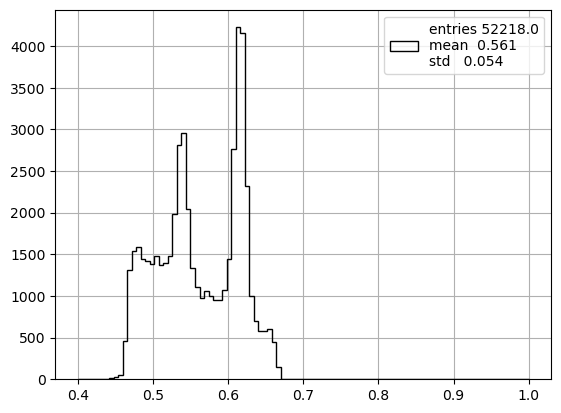

In [73]:
pltext.hist(esum.Ec, 100, (0.4, 1.));

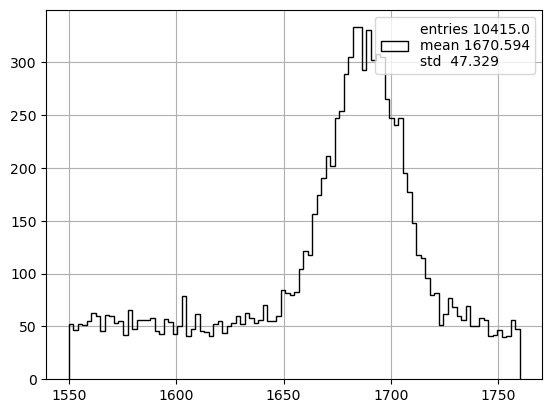

In [39]:
pltext.hist(1000.*esum.Ec, 100, range = (1550, 1760));

In [56]:
pol = getattr(np.polynomial, "Polynomial")

In [65]:
pol([1, 2])(np.array((1, 2, 3, 4)))

array([3., 5., 7., 9.])

In [46]:
f(np.arange(10))

array([ 1,  3,  5,  7,  9, 11, 13, 15, 17, 19])

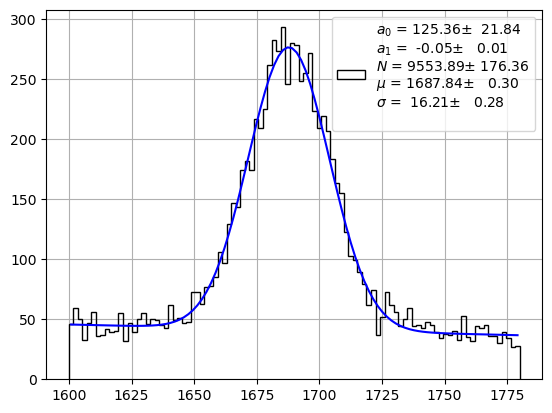

In [67]:
pltext.hfit(1000.*esum.Ec, 100, fun = 'Polynomial.1+gaus', range = (1600, 1780));

In [27]:
dst_summ, reco_summ, eff_summ = pd.DataFrame([]), pd.DataFrame([]), pd.DataFrame([])
for run_n in run_numbers:
    filename = pathdata + f"run_cut_{run_n}.h5"
    #path= path.format(run_folder = run_folder, run_number = run_n) + run_summary_name.format(run_n)
    run_dst  = pd.read_hdf(filename, 'DST/Events')
    run_dst['run_n'] = str(run_n)
    run_reco = pd.read_hdf(filename, 'RECO/Events_summary')
    eff = pd.read_hdf(filename, 'RUN/eff')
    eff['run_n'] = run_n

    dst_summ = dst_summ.append(run_dst)
    reco_summ = reco_summ.append(run_reco)
    eff_summ = eff_summ.append(eff)

In [37]:
reco_summ = reco_summ.fillna({'Ec_drop_in': 0, 'Ec_drop_out':0})
reco_summ['total_energy_d'] = reco_summ['total_energy'] - reco_summ['Ec_drop_out'] # - reco_summ['Ec_drop_in']

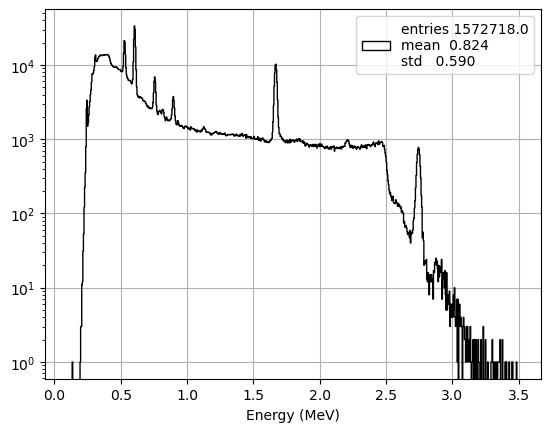

In [49]:
pltext.hist(reco_summ.total_energy_d, 800, (.1, 3.5));
plt.xlabel('Energy (MeV)'); plt.yscale('log');

In [ ]:
def get_peak(energy, bins = 100, range = (0, 3e3))
    _, _, _, pars, epars, _ = histos.hfit(energy, bins, fun = "gaus+exp", range = range)
    


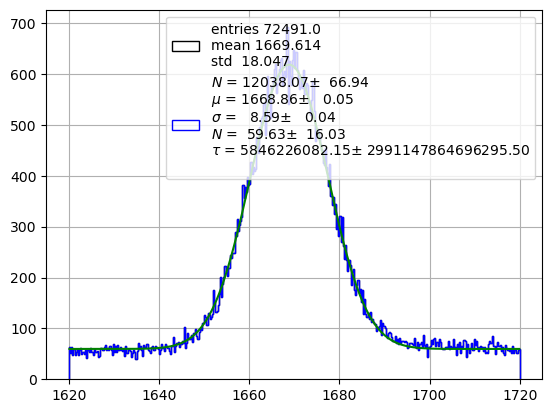

In [64]:
scale = 1e3
pltext.hist(scale*reco_summ.total_energy_d, 400, (scale*1.62, scale*1.72));
pltext.hfit(scale*reco_summ.total_energy_d, 400, fun = 'gaus+exp', range = (scale*1.62, scale*1.72));

In [209]:
reco_summ

,event,npeak,run_n,file_n,ldc_n,time,dX,dY,dZ,Xmin,...,Y_bary,Z_bary,total_E,total_energy,num_hits,Ec_drop_in,nhits_drop_in,Ec_drop_out,nhits_drop_out,total_energy_d
11,120,32,15589,0000,ldc1,1.751990e+09,400.30,277.40,163.531875,-19.125,...,-140.575041,663.460993,339022.818697,1.852308,1261,0.041174,83,0.008404,21,1.843904
43,442,32,15589,0000,ldc1,1.751990e+09,107.85,107.85,63.406375,88.725,...,43.714905,912.947330,63996.899463,0.351425,229,0.012001,13,0.004922,16,0.346503
65,687,21,15589,0000,ldc1,1.751990e+09,170.05,170.05,147.313125,134.375,...,-219.095438,819.622523,331282.290316,1.794716,1286,0.040074,74,0.006229,10,1.788487
23,883,18,15589,0001,ldc1,1.751990e+09,123.40,123.40,27.127250,-328.125,...,-61.531167,919.496907,69378.268448,0.386220,253,0.006537,12,0.014065,16,0.372155
53,1135,36,15589,0001,ldc1,1.751990e+09,215.70,154.00,78.885000,-312.575,...,-37.438234,398.525620,143315.489953,0.755627,486,0.014002,31,0.008478,14,0.747150
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
0,3828076,18,15597,5370,ldc7,1.752674e+09,185.60,262.35,127.080500,-96.875,...,159.308605,693.238208,110677.212640,0.598111,456,0.020475,38,0.001844,12,0.596266
13,3828230,22,15597,5370,ldc7,1.752674e+09,138.95,138.95,26.769250,288.875,...,-6.786320,577.540461,64412.395411,0.366932,223,0.008872,22,0.006377,9,0.360555
47,3828531,31,15597,5370,ldc7,1.752674e+09,170.05,339.10,47.254250,-81.325,...,103.155084,935.400033,114267.442543,0.617315,479,0.018765,29,0.003201,4,0.614114
54,3828566,19,15597,5370,ldc7,1.752674e+09,123.40,462.50,71.389000,104.275,...,-75.092490,851.997868,64883.624815,0.359839,249,0.019170,22,0.004064,20,0.355775


In [219]:
run_n = run_numbers[0]
energy = reco_summ[reco_summ.run_n == str(run_n) ].total_energy_d
print(len(energy))
#pltext.hist(1e3*energy, 500, (0, 3.8e6));

206103


In [220]:
run_n = run_numbers[0]
energy = reco_summ[reco_summ.run_n == str(run_n)].total_energy_d.values
bins   = 400
range = (1620, 1720)
def get_peak(energy, range, bins = 100):
    _, _, _, pars, epars, _ = histos.hfit(energy, bins, fun = "gaus+exp", range = range)
    mu, sigma = pars[1], pars[2]
    emu, esigma = epars[1], epars[2]
    return mu, emu, sigma, esigma

In [221]:
peak_ranges   = [(0.5, 0.58), (0.58, 0.65), (0.72, 0.81), (0.85, 0.95), (1.62, 1.75), (2.7, 2.8)]
peak_ranges_d = [(0.48, 0.56), (0.57, 0.64), (0.71, 0.80), (0.85, 0.95), (1.59, 1.72), (2.68, 2.79)]

/Users/hernando/miniconda/envs/IC-3.8-2022-04-13/lib/python3.8/site-packages/scipy/optimize/minpack.py:833: OptimizeWarning: Covariance of the parameters could not be estimated
  warnings.warn('Covariance of the parameters could not be estimated',
/Users/hernando/miniconda/envs/IC-3.8-2022-04-13/lib/python3.8/site-packages/scipy/optimize/minpack.py:833: OptimizeWarning: Covariance of the parameters could not be estimated
  warnings.warn('Covariance of the parameters could not be estimated',


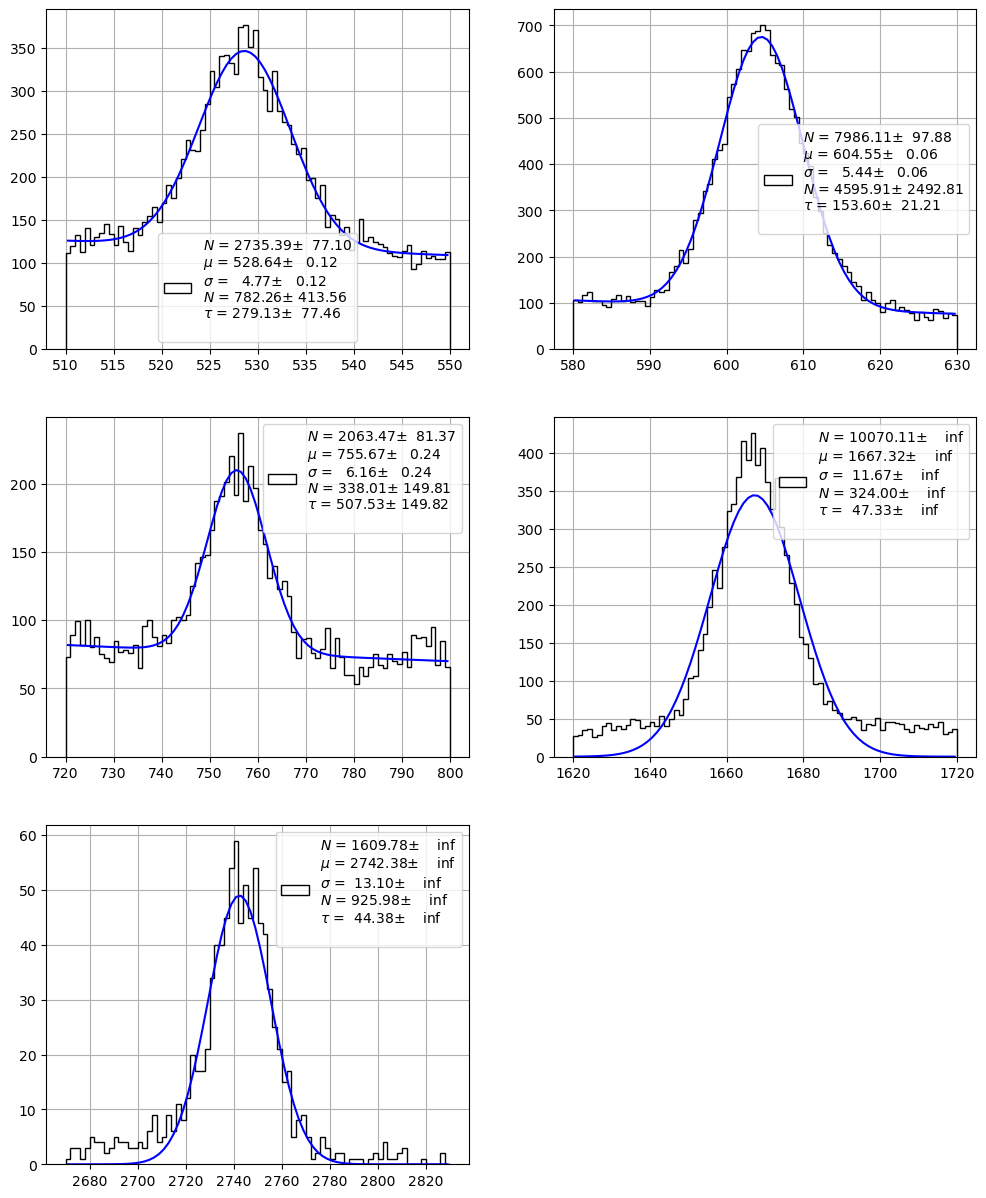

In [223]:
pranges  = [(0.51, 0.55), (0.58, 0.63), (0.72, 0.80), (1.62, 1.72), (2.67, 2.83)]
cv = pltext.canvas(6, 2)
p0 = np.array((1e2, 0.53, 0.05))
#for i, irange in enumerate(peak_ranges_d):
i = 5
for i, irange in enumerate(pranges):
    cv(i+1); pltext.hfit(1e3*energy, fun = 'gaus+exp', bins = 80, range = 1e3*np.array(irange));
#vals = [get_peak(energy, range) for range in peak_ranges_d]

In [196]:
pranges  = [(0.51, 0.55), (0.58, 0.63), (0.72, 0.80), (1.62, 1.72), (2.67, 2.83)]
vals = [get_peak(1e3*energy, range = 1e3*np.array(irange), bins = 400) for irange in pranges]#vals = [get_peak(energy, range) for range in peak_ranges_d]

In [197]:
vals

[(529.1221765269046,
  0.04312056612790292,
  4.999026251331807,
  0.04663885827662838),
 (605.1350336390645,
  0.023814021632212645,
  5.4754554218904,
  0.023210208268350734),
 (756.5705992685588,
  0.08337091634140209,
  6.162107646604556,
  0.08365794396834988),
 (1668.8612462301135,
  0.04876067731261533,
  8.593481308799348,
  0.04452136548869566),
 (2745.03749804094,
  0.19411825846338812,
  12.365539322467907,
  0.17479739947992182)]

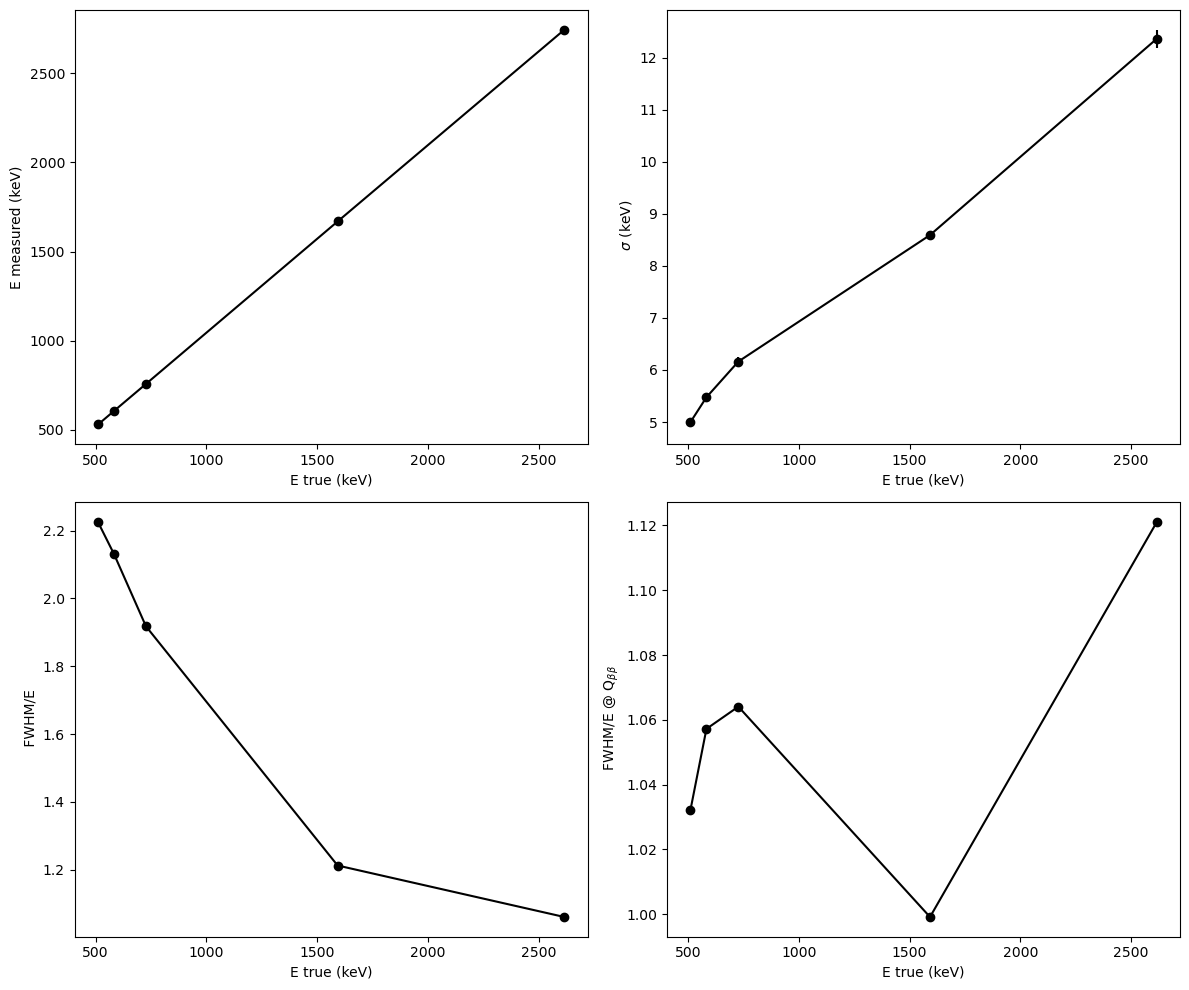

In [207]:
peak_true  = 1e3*np.array([0.511, 0.583, 0.727, 1.592, 2.615])
peak_meas  = np.array([v[0] for v in vals])
peak_emeas = np.array([v[1] for v in vals])
peak_sig   = np.array([v[2] for v in vals])
peak_esig  = np.array([v[3] for v in vals])
Qbb = 2458.
cv = pltext.canvas(3, 2)
cv(1); plt.errorbar(peak_true, peak_meas, yerr = peak_emeas, marker= 'o');
plt.xlabel("E true (keV)"); plt.ylabel("E measured (keV)")
cv(2); plt.errorbar(peak_true, peak_sig, yerr = peak_esig, marker= 'o');
plt.xlabel("E true (keV)"); plt.ylabel(r" $\sigma$ (keV)")
cv(3); plt.plot(peak_true, 235.48 * peak_sig/peak_meas, marker= 'o');
plt.xlabel("E true (keV)"); plt.ylabel(r" FWHM/E")
cv(4); plt.plot(peak_true, 235.48 * peak_sig /peak_meas * np.sqrt(peak_meas/Qbb), marker= 'o');
plt.xlabel("E true (keV)"); plt.ylabel(r" FWHM/E @ Q$_{\beta\beta}$")
plt.tight_layout();


In [ ]:
pltext.hist(reco_summ.total_energy_d, 500, (0, 3));

,event,npeak,run_n,file_n,ldc_n,time,dX,dY,dZ,Xmin,...,X_bary,Y_bary,Z_bary,total_E,total_energy,num_hits,Ec_drop_in,nhits_drop_in,Ec_drop_out,nhits_drop_out
11,120,32,15589,0000,ldc1,1.751990e+09,400.30,277.40,163.531875,-19.125,...,268.259795,-140.575041,663.460993,339022.818697,1.852308,1261,0.041174,83,0.008404,21
43,442,32,15589,0000,ldc1,1.751990e+09,107.85,107.85,63.406375,88.725,...,139.036401,43.714905,912.947330,63996.899463,0.351425,229,0.012001,13,0.004922,16
65,687,21,15589,0000,ldc1,1.751990e+09,170.05,170.05,147.313125,134.375,...,211.142176,-219.095438,819.622523,331282.290316,1.794716,1286,0.040074,74,0.006229,10
23,883,18,15589,0001,ldc1,1.751990e+09,123.40,123.40,27.127250,-328.125,...,-267.817024,-61.531167,919.496907,69378.268448,0.386220,253,0.006537,12,0.014065,16
53,1135,36,15589,0001,ldc1,1.751990e+09,215.70,154.00,78.885000,-312.575,...,-168.523569,-37.438234,398.525620,143315.489953,0.755627,486,0.014002,31,0.008478,14
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
0,3828076,18,15597,5370,ldc7,1.752674e+09,185.60,262.35,127.080500,-96.875,...,-15.589238,159.308605,693.238208,110677.212640,0.598111,456,0.020475,38,0.001844,12
13,3828230,22,15597,5370,ldc7,1.752674e+09,138.95,138.95,26.769250,288.875,...,355.499240,-6.786320,577.540461,64412.395411,0.366932,223,0.008872,22,0.006377,9
47,3828531,31,15597,5370,ldc7,1.752674e+09,170.05,339.10,47.254250,-81.325,...,1.523561,103.155084,935.400033,114267.442543,0.617315,479,0.018765,29,0.003201,4
54,3828566,19,15597,5370,ldc7,1.752674e+09,123.40,462.50,71.389000,104.275,...,163.573332,-75.092490,851.997868,64883.624815,0.359839,249,0.019170,22,0.004064,20
